## סקאלות לוגריתמיות — ומתי משתמשים בהן

מסלול הזריקה שלנו לא דורש סולם לוגריתמי — הערכים נמצאים כולם באותו סדר גודל. אבל כשגודל פיזיקלי משתנה על פני **כמה סדרי גודל**, סולם ליניארי "דוחס" את הערכים הקטנים לכדי קו אחד צמוד לציר, והגרף הופך חסר תועלת. הפתרון:

```python
ax.set_xscale("log")
ax.set_yscale("log")
```

אפשר להפעיל את שניהם יחד (log-log), רק אחד מהם, או אף אחד — תלוי בטווח הערכים בכל ציר בנפרד.

### דוגמה: טווח הזריקה כתלות במהירות ההתחלתית

הטווח נתון על ידי $R(v_0) = v_0^2 \sin(2\theta)/g$ — תלות **ריבועית** ב-$v_0$. אם נסרוק $v_0$ על פני טווח רחב (למשל בין 1 ל-1000 מ/ש, כתרחיל מתמטי גרידא, לא ערכים פיזיקליים סבירים לזריקת יד), $R$ ישתנה על פני כמה סדרי גודל, ונשווה תצוגה ליניארית מול log-log.

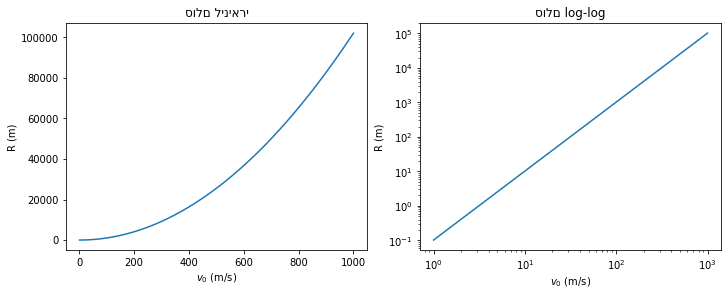

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g, v0 = 9.8, 20.0          # m/s^2, m/s
theta = np.radians(45)
v0_range = np.logspace(0, 3, 200)     # 1 ... 1000, פרוש לוגריתמי
R_range = v0_range**2 * np.sin(2 * theta) / g

fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axs[0].plot(v0_range, R_range)
axs[0].set_title("סולם ליניארי")
axs[0].set_xlabel(r"$v_0$ (m/s)")
axs[0].set_ylabel("R (m)")

axs[1].plot(v0_range, R_range)
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_title("סולם log-log")
axs[1].set_xlabel(r"$v_0$ (m/s)")
axs[1].set_ylabel("R (m)")

plt.show()

בגרף הליניארי (משמאל) כמעט כל המידע על ערכי $v_0$ הקטנים "נעלם" צמוד לציר. בגרף ה-log-log (מימין) רואים קו ישר — תוצאה של חוק חזקה ($R\propto v_0^2$); לחילוץ השיפוע כדי לזהות את המעריך נחזור בסעיף 12.3.

חשוב: `np.logspace(0, 3, 200)` יוצר רשת של 200 נקודות הפרוסות **אחיד בסולם הלוגריתמי** בין $10^0$ ל-$10^3$ — לא בין 0 ל-1000 ליניארית. זה ההבדל בינה לבין `np.linspace`.

### נסו בעצמכם

לפעמים רק ציר אחד דורש סולם לוגריתמי (למשל כשהערכים חיוביים אך משתנים בכמה סדרי גודל, וציר ה-x נשאר ליניארי). ציירו את `R_range` כתלות ב-`v0_range` עם `ax.set_yscale("log")` בלבד (בלי log על ה-x).

In [2]:
# fig, ax = plt.subplots()
# ax.plot(v0_range, R_range)
# ax.set_yscale(...)
# ...

`````{admonition} פתרון
:class: dropdown, tip
```python
fig, ax = plt.subplots()
ax.plot(v0_range, R_range)
ax.set_yscale("log")
ax.set_xlabel(r"$v_0$ (m/s)")
ax.set_ylabel("R (m)")
plt.show()
```
`````

### בדקו את עצמכם

In [3]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "מתי הכי הגיוני להשתמש בסולם לוגריתמי בציר?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "כשכל הערכים דומים בגודלם", "correct": False, "feedback": "אז דווקא סולם ליניארי מספיק ואף עדיף."},
            {"answer": "כשהערכים משתרעים על פני כמה סדרי גודל", "correct": True, "feedback": "נכון."},
            {"answer": "תמיד, בכל גרף", "correct": False, "feedback": "לא — יש מקרים שסולם לוגריתמי מטעה או מיותר."},
            {"answer": "רק כשיש ערכים שליליים בנתונים", "correct": False, "feedback": "לא קשור — לוג לא מוגדר עבור ערכים שליליים או אפס, כך שדווקא אז אי אפשר להשתמש בו ישירות."}
        ]
    },
    {
        "question": "מה ההבדל בין <code>np.linspace(1, 1000, 200)</code> ל-<code>np.logspace(0, 3, 200)</code>?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "אין הבדל, שתיהן זהות", "correct": False, "feedback": "לא נכון."},
            {"answer": "logspace תמיד מחזיר מספרים שלמים", "correct": False, "feedback": "לא נכון."},
            {"answer": "linspace פורש נקודות אחיד בסולם ליניארי; logspace פורש אחיד בסולם הלוגריתמי (בין 10^0 ל-10^3)", "correct": True, "feedback": "נכון."},
            {"answer": "linspace תמיד מתחיל מ-0, logspace לא", "correct": False, "feedback": "לא — שתי הפונקציות מקבלות נקודת התחלה כפרמטר; ההבדל הוא בפריסה (ליניארית מול לוגריתמית), לא בנקודת ההתחלה."}
        ]
    }
]
display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

ציירו את $R(v_0)$ עבור שלוש זוויות שונות (30°, 45°, 60°) יחד על אותו גרף log-log, עם מקרא.

In [4]:
# for angle in [30, 45, 60]:
#     ...

`````{admonition} פתרון
:class: dropdown, tip
```python
fig, ax = plt.subplots()
for angle in [30, 45, 60]:
    theta_i = np.radians(angle)
    R_i = v0_range**2 * np.sin(2 * theta_i) / g
    ax.plot(v0_range, R_i, label=fr"$\theta={angle}^\circ$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$v_0$ (m/s)")
ax.set_ylabel("R (m)")
ax.legend()
plt.show()
```
`````